In [2]:
import pandas as pd
df = pd.read_csv('medical_insurance.csv', na_values = "?")
print("Raw shape:", df.shape)
print(df.head())

Raw shape: (100000, 54)
   person_id  age     sex   region urban_rural   income     education  \
0      75722   52  Female    North    Suburban  22700.0     Doctorate   
1      80185   79  Female    North       Urban  12800.0         No HS   
2      19865   68    Male    North       Rural  40700.0            HS   
3      76700   15    Male    North    Suburban  15600.0  Some College   
4      92992   53    Male  Central    Suburban  89600.0     Doctorate   

  marital_status employment_status  household_size  ...  liver_disease  \
0        Married           Retired               3  ...              0   
1        Married          Employed               3  ...              0   
2        Married           Retired               5  ...              0   
3        Married     Self-employed               5  ...              0   
4        Married     Self-employed               2  ...              0   

   arthritis mental_health proc_imaging_count  proc_surgery_count  \
0          1           

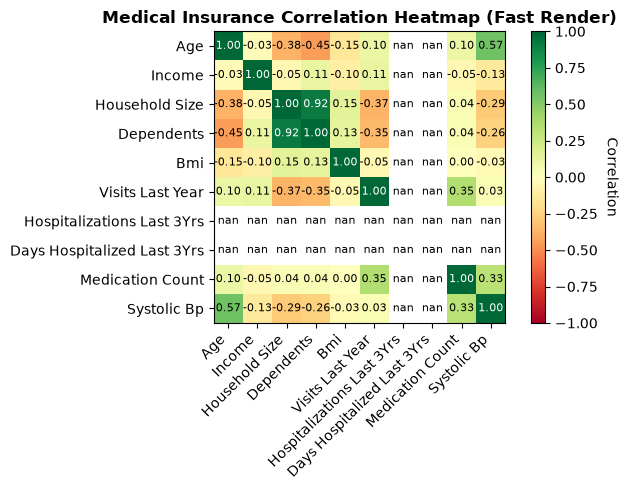

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fast disk load (50 rows only)
df = pd.read_csv("medical_insurance.csv", nrows=50)

# 2. Select numeric columns and cap at 10 max to prevent rendering freeze
cols_to_exclude = ["id", "person_id", "unnamed: 0"]
num_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns 
    if col.lower() not in cols_to_exclude
][:10]  # Caps at top 10 features

# Calculate correlation matrix
corr_matrix = df[num_cols].corr()

# 3. Fast Plot Generation
plt.figure(figsize=(7, 5))
im = plt.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)

# Annotate cells
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr_matrix.iloc[i, j]
        plt.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color="white" if abs(val) > 0.6 else "black",
            fontsize=8
        )

plt.xticks(range(len(num_cols)), [c.replace("_", " ").title() for c in num_cols], rotation=45, ha="right")
plt.yticks(range(len(num_cols)), [c.replace("_", " ").title() for c in num_cols])

cbar = plt.colorbar(im)
cbar.set_label("Correlation", rotation=270, labelpad=15)
plt.title("Medical Insurance Correlation Heatmap (Fast Render)", fontweight="bold")

plt.tight_layout()
plt.show()